d:\AgenticBlogger\core\nodes\research_node.py:10: LangChainDeprecationWarning: The class `TavilySearchResults` was deprecated in LangChain 0.3.25 and will be removed in 1.0. An updated version of the class exists in the `langchain-tavily package and should be used instead. To use it run `pip install -U `langchain-tavily` and import as `from `langchain_tavily import TavilySearch``.
  tool = TavilySearchResults(max_results=6,api_key = os.getenv("TAVILY_API_KEY"))


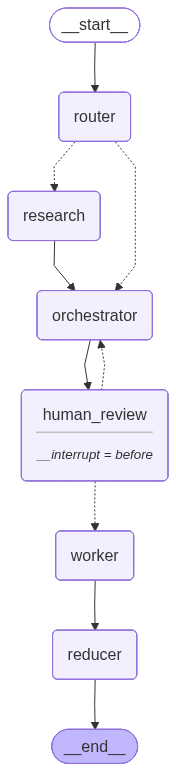

In [1]:
from langgraph.graph import StateGraph, START, END
from core.models.models import State
from core.nodes.orchestrator import orchestrator
from core.nodes.fanout import fanout
from core.nodes.worker import worker_node
from core.nodes.human_approval import human_review_node
from core.nodes.router_node import router_node, route_next, route_after_review
from core.nodes.research_node import research_node
from core.nodes.generate_img import merge_content, decide_images, generate_and_place_images
from langgraph.checkpoint.memory import InMemorySaver

checkpointer= InMemorySaver()
# subgraph for image generation -> REDUCER
reducer_graph = StateGraph(State)
reducer_graph.add_node("merge_content", merge_content)
reducer_graph.add_node("decide_images", decide_images)
reducer_graph.add_node("generate_and_place_images", generate_and_place_images)
reducer_graph.add_edge(START, "merge_content")
reducer_graph.add_edge("merge_content", "decide_images")
reducer_graph.add_edge("decide_images", "generate_and_place_images")
reducer_graph.add_edge("generate_and_place_images", END)
reducer_subgraph = reducer_graph.compile()



g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator)
g.add_node("worker", worker_node)
g.add_node("reducer", reducer_subgraph)
g.add_node("human_review", human_review_node)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")
g.add_edge("orchestrator","human_review")
g.add_conditional_edges("human_review", route_after_review, ["orchestrator", "worker"])
# g.add_conditional_edges("human", fanout, {
#     "worker" : "worker",
#     "orchestrator" : "orchestrator"
# })
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile(
    checkpointer=checkpointer,
    interrupt_before=["human_review"]
    )

app